In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("property_data.csv")

# Drop unnecessary column
df = df.drop(columns=['Unnamed: 10'], errors='ignore')

# Drop rows with critical missing values
df.dropna(subset=['bed', 'bath', 'house_size'], inplace=True)

# Fill missing optional fields
df['brokered_by'] = df['brokered_by'].fillna(-1)
df['zip_code'] = df['zip_code'].fillna(-1)
df['city'] = df['city'].fillna('Unknown')

# Convert to numeric (if not already)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['bed'] = pd.to_numeric(df['bed'], errors='coerce')
df['bath'] = pd.to_numeric(df['bath'], errors='coerce')
df['house_size'] = pd.to_numeric(df['house_size'], errors='coerce')

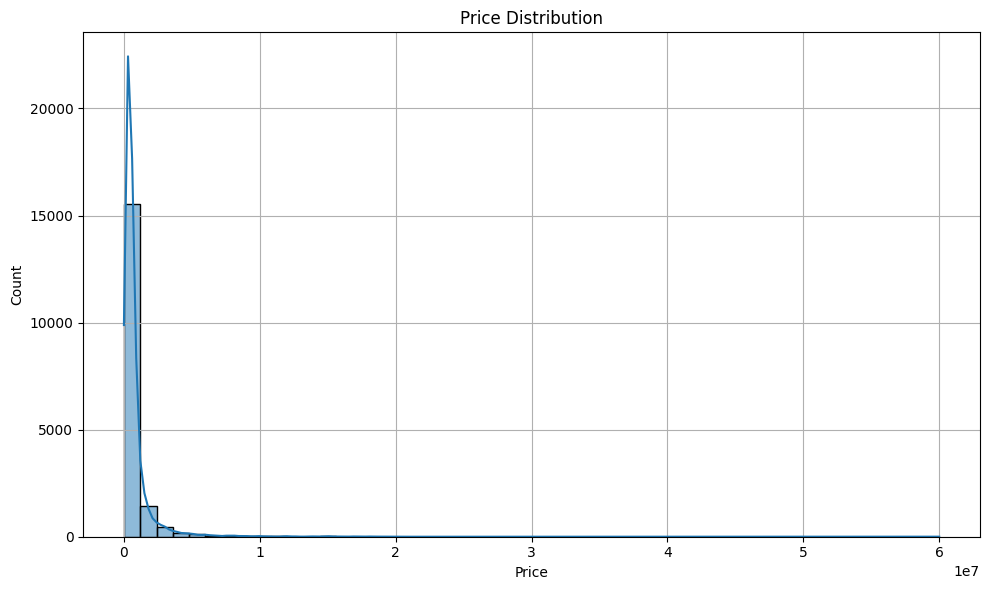

In [3]:
# 1. Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

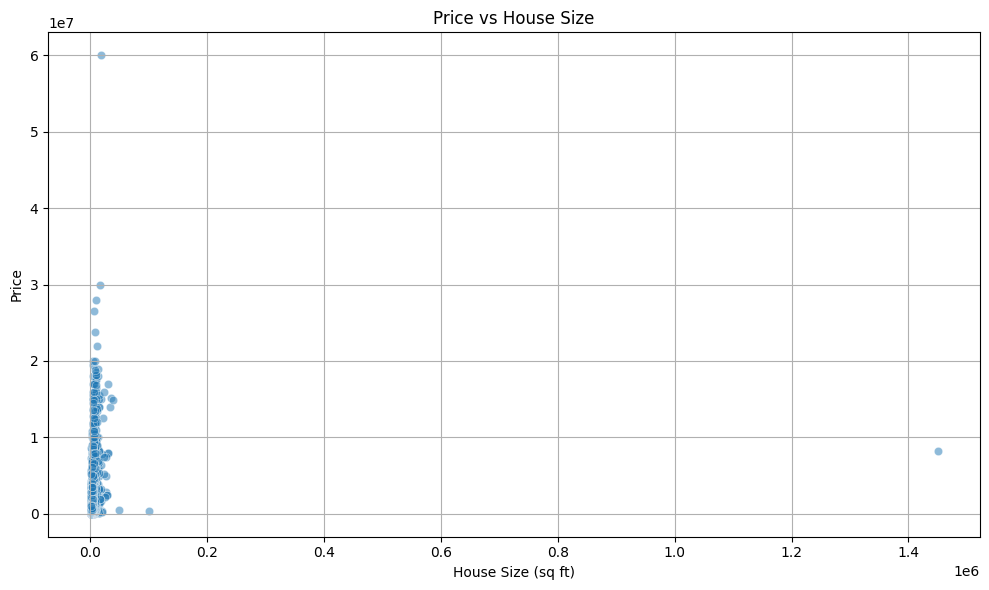

In [4]:
# 2. Price vs House Size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='house_size', y='price', data=df, alpha=0.5)
plt.title("Price vs House Size")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()

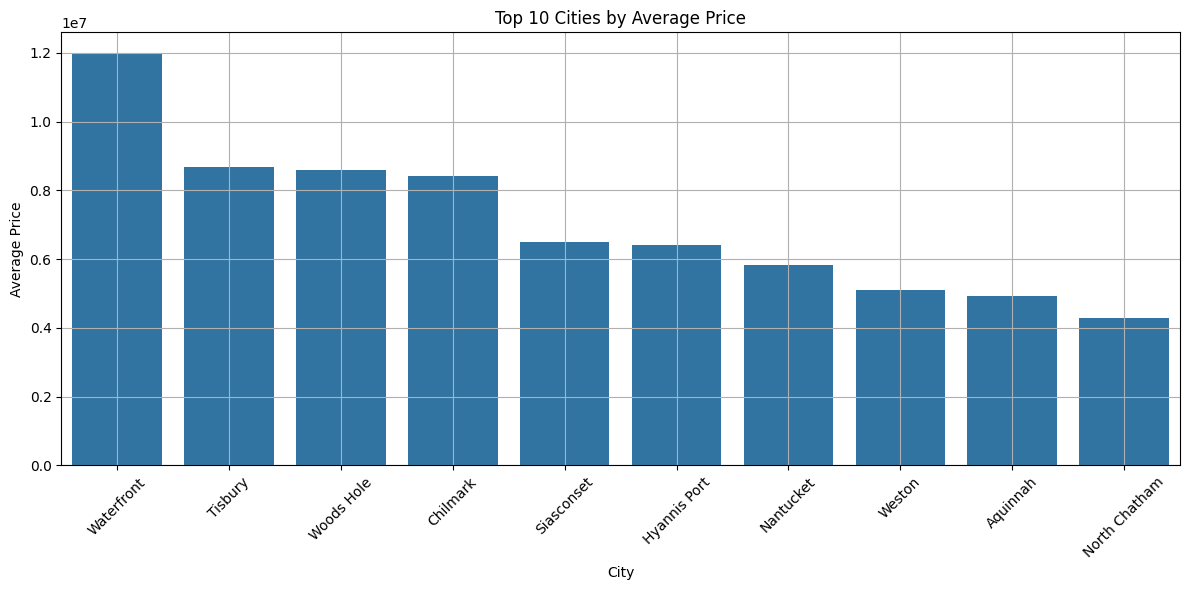

In [5]:
# 3. Average Price by City (Top 10)
top_cities = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Average Price")
plt.ylabel("Average Price")
plt.xlabel("City")
plt.grid(True)
plt.tight_layout()
plt.show()

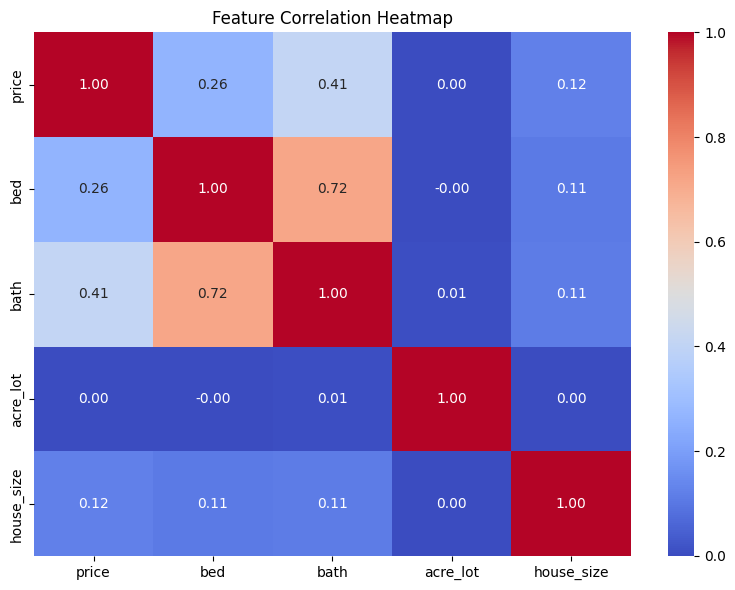

In [6]:
# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[['price', 'bed', 'bath', 'acre_lot', 'house_size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Top 10 Cities by Median Price'}, xlabel='city'>

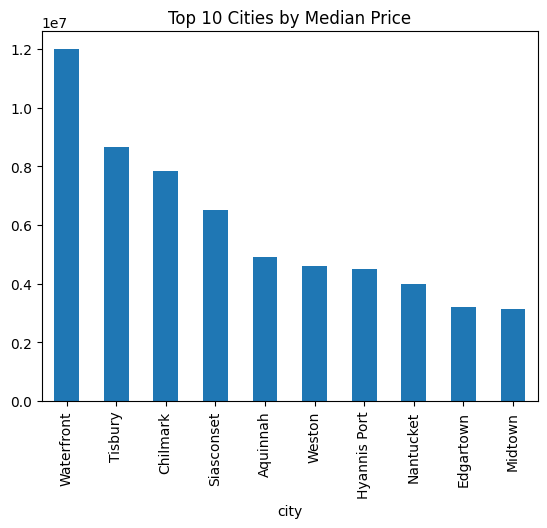

In [7]:
city_price = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)
city_price.plot(kind='bar', title='Top 10 Cities by Median Price')
